In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

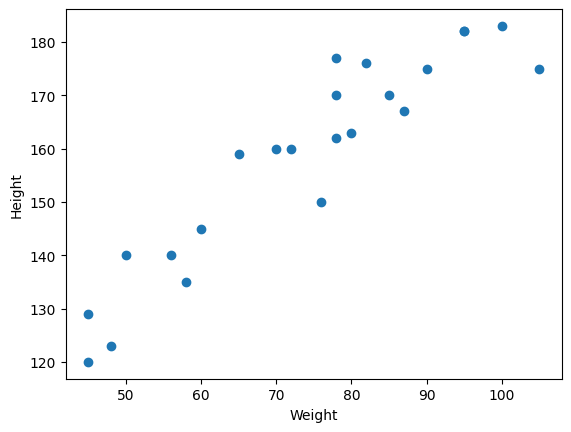

In [6]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [7]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


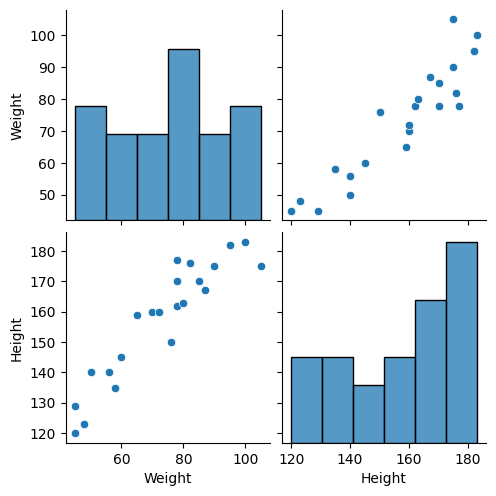

In [8]:
import seaborn as sns
sns.pairplot(df)

In [9]:
X = df[['Weight']]
y = df['Height']

In [10]:
type(X)
type(y)

pandas.core.series.Series

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 42)

In [12]:
X_train.shape

(18, 1)

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
lr = LinearRegression()

In [17]:
lr.fit(X_train, y_train)

LinearRegression()

In [18]:
lr.coef_

array([17.03440872])

In [19]:
lr.intercept_

157.5

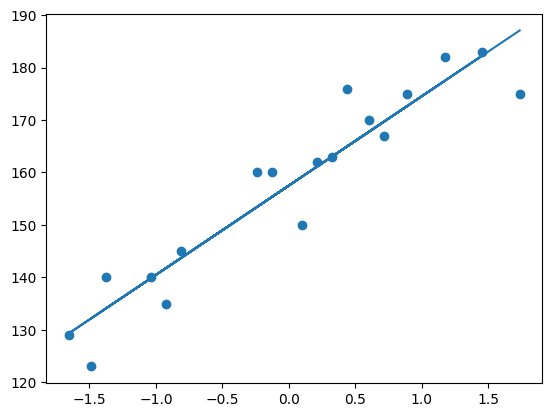

In [20]:
plt.scatter(X_train, y_train)
plt.plot(X_train, lr.predict(X_train))

In [21]:
y_pred = lr.predict(X_test)

C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [23]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse) 
print(mse)
print(mae)
print(rmse)

1571109.7376966465
1225.7843095186977
1253.4391639392184


In [24]:
from sklearn.metrics import r2_score

In [25]:
r2 = r2_score(y_test, y_pred)

In [26]:
print(r2)

-3190.755521080462


In [27]:
pip install statsmodels


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached statsmodels-0.14.5-cp312-cp312-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 1.7 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.6 MB 1.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.6 MB 1.7 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.6 MB 1.7 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.6 MB 1.8 MB/s eta 0:00:05
   ---------- ----------------------------- 2.6/9.6 MB 1.8 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.6 MB 1.8 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.6 MB 1.8 MB/s eta 0:00:04
   --------------- ---------------------

In [29]:
#same linear regression using OLS technique
import statsmodels.api as sm

In [30]:
ols = sm.OLS(y_train, X_train).fit()
ols_pred = ols.predict(X_test)
print(ols_pred)
ols.summary()

15    1328.683880
9     1328.683880
0      766.548392
8     1618.268828
17    1107.236567
dtype: float64


C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.047
Method:                 Least Squares   F-statistic:                             0.1986
Date:                Tue, 04 Nov 2025   Prob (F-statistic):                       0.661
Time:                        07:02:38   Log-Likelihood:                         -116.62
No. Observations:                  18   AIC:                                      235.2
Df Residuals:                      17   BIC:                                      236.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.0344     38.226      0.446      0.661     -63.616      97.684
==============================================================================
Omnibus:                        0.849   Durbin-Watson:                   0.003
Prob(Omnibus):                  0.654   Jarque-Bera (JB):                0.661
Skew:                          -0.428   Prob(JB):                        0.718
Kurtosis:                       2.614   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""